In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.preprocessing import DataProcessor
from SynOmics.processing.metadata import MetaData

clinical_data = pd.read_csv("NSCLCData/clean_clinical_data.csv").drop(columns = ['Harmonized_SU2C_Participant_ID_v2'])
omics_data = pd.read_csv("NSCLCData/cleaned_rna_expression.csv")
# clinical_data
clinical_data = clinical_data.rename(columns={"Harmonized_SU2C_RNA_Tumor_Sample_ID_v2": "Patient_RNA"})
omics_data = omics_data.rename(columns={"Unnamed: 0": "Patient_RNA"})

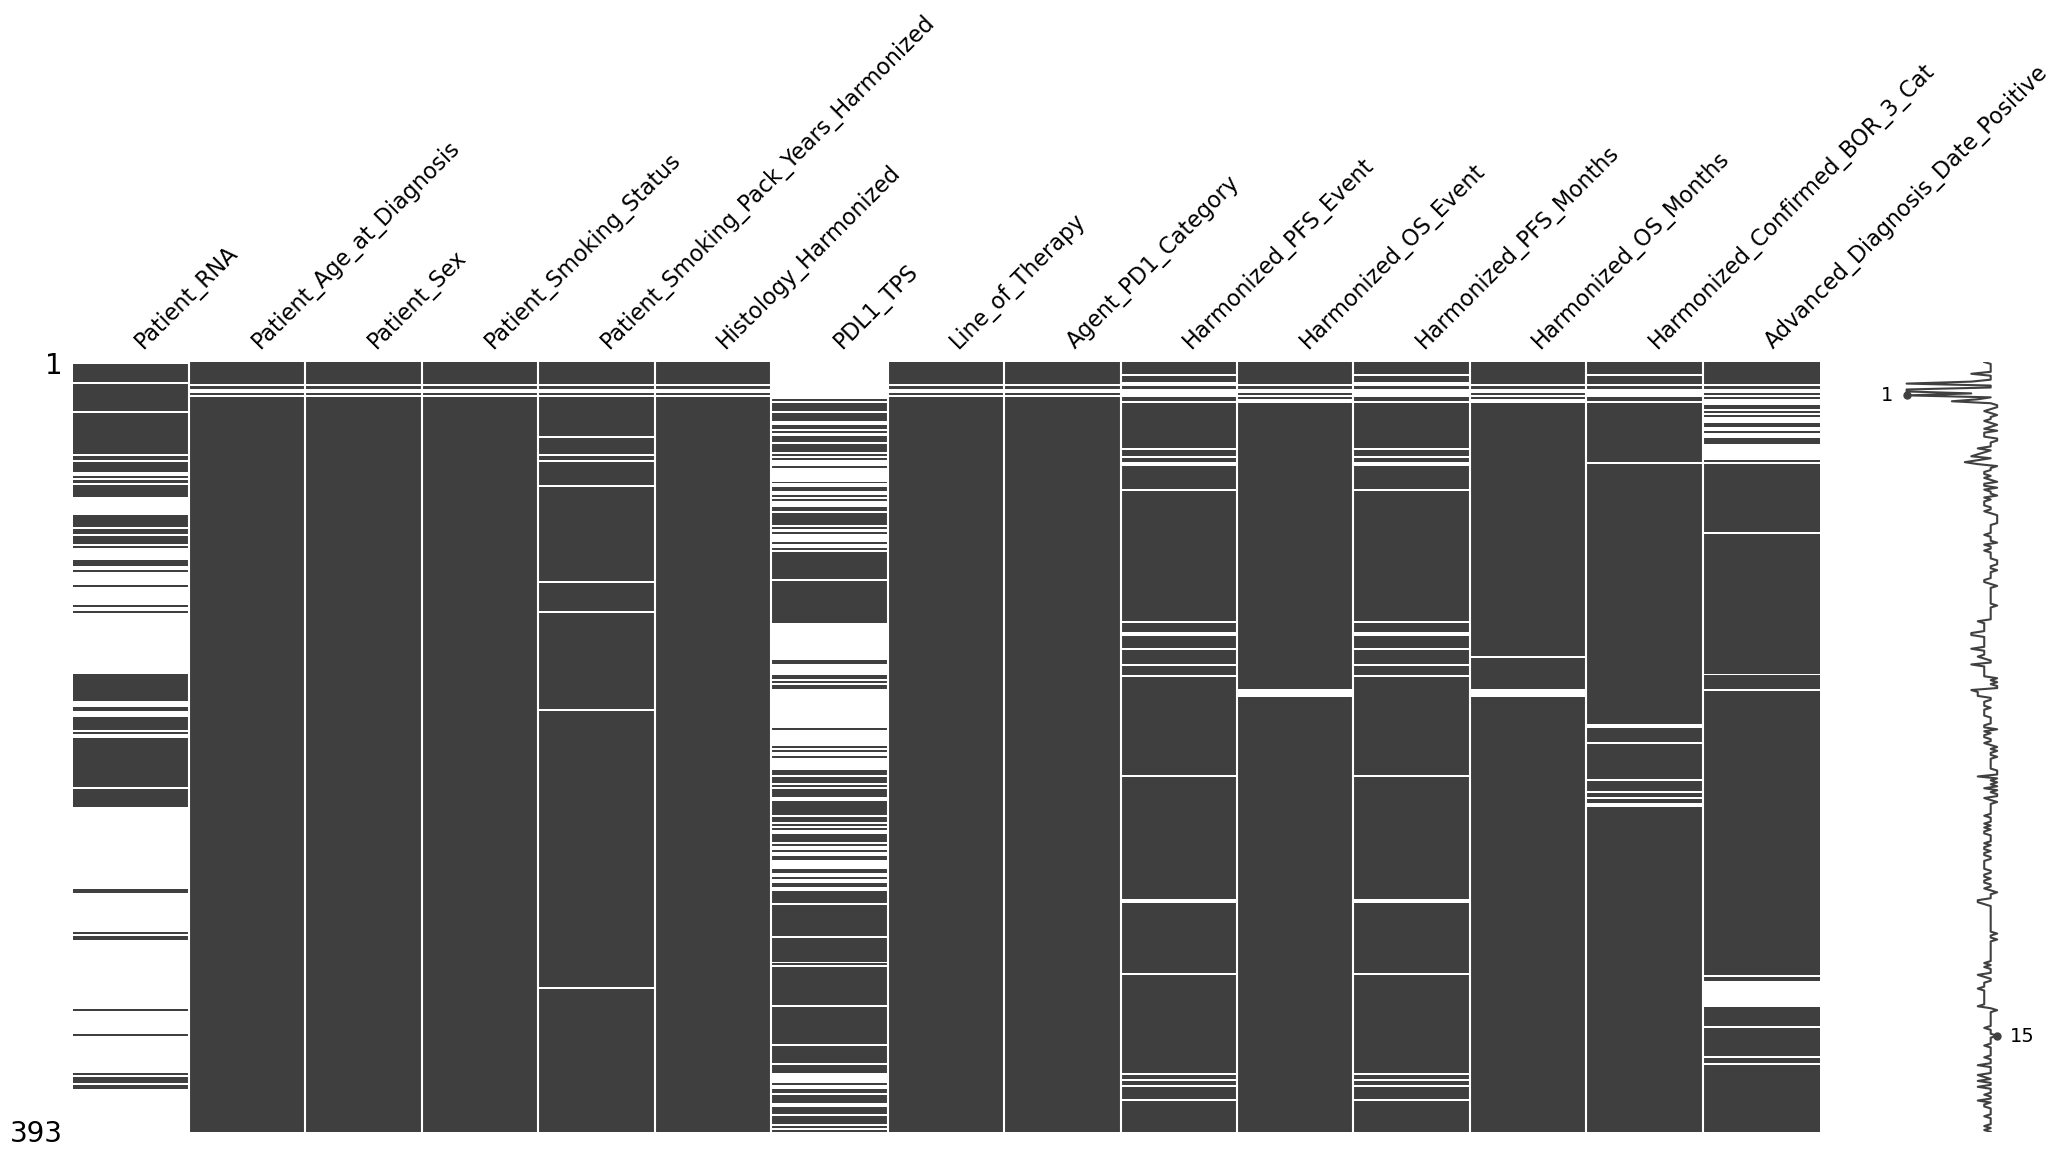

In [2]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(clinical_data)
    
# Adjust layout and show
plt.tight_layout(h_pad=3)
plt.show()

In [3]:
import pandas as pd
from SynOmics.processing.pipeline import DataIntegrationPipeline


# Set output directory for logs/metadata
output_dir = "./Integration_NSCLCData_Final"

# Optional: define imputation hyperparameters for MICE or KNN
# For MICE (miceforest, if available):
imputer = "mice"
imputer_params = {
    "iterations": 10,
    "n_estimators": 100,
    "random_state": 42
}


# Known ordinal categorical columns in clinical data
ordinal_cat_columns = ['Patient_Smoking_Status','Line_of_Therapy']

# Steps config (optional, defaults to all True)
steps_config = {
    "remove_undefined": True,
    "remove_duplicates": True,
    "remove_overmissing_samples": True,
    "check_duplicate_genes": True,
    "mapping_genes": False,
    "feature_engineering": True,
    "integrate_data": True
}

# Create and run the pipeline
pipeline = DataIntegrationPipeline(output_dir=output_dir, logger="Integration_NSCLC")

results = pipeline.run_pipeline(
    clinical_data=clinical_data,
    transcriptomics_data=omics_data,
    clinical_id_column="Patient_RNA",
    transcriptomics_id_column="Patient_RNA",
    integration_id_column="Patient_ID",
    steps_config=steps_config,
    overmissing_samples_threshold=100,      # percent
    overmissing_features_threshold=100,     # percent
    unique_threshold=10,
    scaler="minmax",
    ordinal_cat_columns=ordinal_cat_columns,
    imputer=imputer,
    imputer_params=imputer_params,
    add_indicators=True,
    verbose=True,
)

2025-12-25 23:58:17 - DEBUG - Standalone logger initialized successfully.
2025-12-25 23:58:17 - INFO - === STARTING DATA INTEGRATION PIPELINE ===
2025-12-25 23:58:17 - INFO - [CONFIG] Steps: {'remove_undefined': True, 'remove_duplicates': True, 'remove_overmissing_samples': True, 'check_duplicate_genes': True, 'mapping_genes': False, 'feature_engineering': True, 'integrate_data': True}
2025-12-25 23:58:17 - DEBUG - Standalone logger initialized successfully.
2025-12-25 23:58:17 - INFO - [TRANSCRIPTOMICS] Initial shape: rows=152, cols=21970
2025-12-25 23:58:17 - INFO - [T1] Removing undefined samples missing ID in 'Patient_RNA'
2025-12-25 23:58:17 - INFO - [T1] Removed 0 rows; new shape: rows=152, cols=21970 (took 0.03s)
2025-12-25 23:58:17 - INFO - [T2.1] Removing duplicate columns
2025-12-25 23:58:17 - INFO - [T2.1] Removed 0 duplicate columns; cols=21970 (took 0.01s)
2025-12-25 23:58:17 - INFO - [T2.2] Removing duplicate rows
2025-12-25 23:58:19 - INFO - [T2.2] Removed 0 duplicate ro

Processing duplicates: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:06<00:00,  1.19it/s]

2025-12-25 23:58:26 - INFO - Duplicate gene information saved to ./Integration_NSCLCData_Final
2025-12-25 23:58:26 - INFO - [T4.1] Found 8 duplicate gene(s) (took 6.92s)
2025-12-25 23:58:26 - INFO - [T4.2] Skipped mapping_genes
2025-12-25 23:58:26 - INFO - [T5] Feature engineering (remove over-missing features > 100%, impute via MICE)


FEATURE ENGINEERING - OVERMISSING: Removing features with missing > 100%
FEATURE ENGINEERING - METADATA: Transcriptomics → all numerical
FEATURE ENGINEERING - IMPUTATION: Using MICE
Index(['WASH7P', 'RP11-34P13.15', 'RP11-34P13.16', 'ABC7-43046700E7.1',
       'RP11-34P13.18', 'RPL23AP21', 'RPL23AP24', 'RP4-669L17.10', 'SEPT14P13',
       'MTATP6P1',
       ...
       'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=21969)

MICE failed (ValueError: Length of new names must be 1, got 2). Falling back to KNN (n_neighbors=5).
2025-12-25 23:58:29 - INFO - [T5] Feature engineering complete; features shape=(152, 21969) (took 2.49s)
2025-12-25 23:58:29 - INFO - [TRANSCRIPTOMICS] Final shape: rows=152, cols=21970 (total 12.04s)
2025-12-25 23:58:29 - INFO - [CLINICAL] Initial shape: rows=393, cols=15
2025-12-25 23:58:29 - INFO - [C1] Removing undefined samples missing ID in 'Patient_RNA'
2025-12-25 23:58:

In [4]:
integrated_data = results["integrated_data"]
processed_clinical = results["processed_clinical"]
processed_omics = results["processed_transcriptomics"]

#Save dataframes

integrated_data.to_csv("Integration_NSCLCData_Final/integrated_data_nsclc.csv", index = False)
processed_clinical.to_csv("Integration_NSCLCData_Final/processed_clinical_nsclc.csv", index = False)
processed_omics.to_csv("Integration_NSCLCData_Final/processed_transcriptomics_nsclc.csv", index = False)